# Klasifikasi Komentar Judol (Judi Online)

Model untuk mendeteksi komentar spam judol di YouTube menggunakan Machine Learning.

**2 Pendekatan:**
1. TF-IDF + Traditional ML (Logistic Regression, Naive Bayes, Random Forest)
2. LSTM Deep Learning

## 1. Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


## 2. Load Dataset

In [30]:
# Load labeled dataset
df = pd.read_csv('../datasets/comments_labeled_final.csv')
print(f'Total data: {len(df)}')
print(f'Kolom: {df.columns.tolist()}')
df.head()

Total data: 79296
Kolom: ['video_id', 'author', 'comment_text', 'published_at', 'like_count', 'is_promo', 'ai_prob', 'label']


,video_id,author,comment_text,published_at,like_count,is_promo,ai_prob,label
0,YZ4N8jH5R_M,@HermanHerman-tp1us,Maaf bang tapi sekarang km udah gak natural ba...,2025-11-15T23:20:20Z,0,False,0.000016,0
1,YZ4N8jH5R_M,@zallesvhan,Kontennya keren! Terus berkarya bang 🙌\r\nSala...,2025-11-14T09:21:34Z,0,False,0.996698,1
2,YZ4N8jH5R_M,@tedivirgiawan9996,Giliran yg lucu waktu nya cepet bngt😢,2025-11-12T16:07:14Z,0,False,0.002775,0
3,YZ4N8jH5R_M,@entah02,Eh ada Pak jalal 😂😂,2025-11-12T12:39:29Z,0,False,0.003958,0
4,YZ4N8jH5R_M,@FandyFandy-u7d,Sekilas anakNya jarwo mirip te ocah yh..tau cM...,2025-11-12T05:44:36Z,0,False,0.000082,0


Distribusi Label:
label
0    75047
1     4249
Name: count, dtype: int64

Persentase Judol: 5.36%


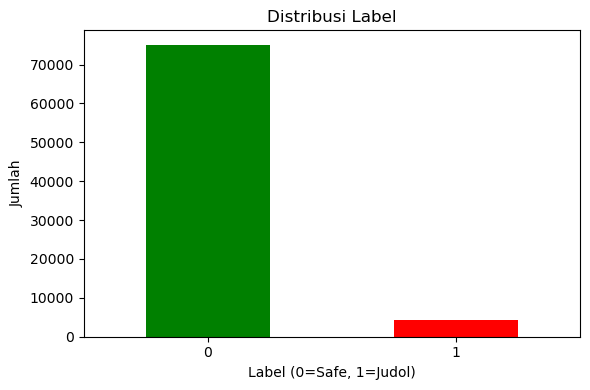

In [31]:
# Cek distribusi label
print('Distribusi Label:')
print(df['label'].value_counts())
print(f"\nPersentase Judol: {df['label'].mean()*100:.2f}%")

# Visualisasi
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribusi Label')
plt.xlabel('Label (0=Safe, 1=Judol)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [32]:
# Drop missing values
df = df.dropna(subset=['comment_text', 'label'])

# Features dan Target
X = df['comment_text'].astype(str)
y = df['label'].astype(int)

print(f'Total samples: {len(X)}')
print(f'Judol (1): {y.sum()}')
print(f'Safe (0): {len(y) - y.sum()}')

Total samples: 79295
Judol (1): 4249
Safe (0): 75046


In [33]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train)}')
print(f'Test set: {len(X_test)}')

Training set: 63436
Test set: 15859


---
# PART A: TF-IDF + Traditional ML
---

## 4. Feature Extraction (TF-IDF)

In [34]:
# TF-IDF Vectorizer dengan char_wb untuk obfuscation
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    analyzer='char_wb',
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Train shape: {X_train_tfidf.shape}')

Vocabulary size: 10000
Train shape: (63436, 10000)


## 5. Train TF-IDF Models

In [35]:
# Logistic Regression
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1: {f1_score(y_test, y_pred_lr):.4f}')

Training Logistic Regression...
Accuracy: 0.9821 | F1: 0.8475


In [36]:
# Naive Bayes
print('Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f} | F1: {f1_score(y_test, y_pred_nb):.4f}')

Training Naive Bayes...
Accuracy: 0.9815 | F1: 0.8168


In [37]:
# Random Forest
print('Training Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, max_depth=50, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1: {f1_score(y_test, y_pred_rf):.4f}')

Training Random Forest...
Accuracy: 0.9753 | F1: 0.7045


## 6. Confusion Matrix - TF-IDF Models

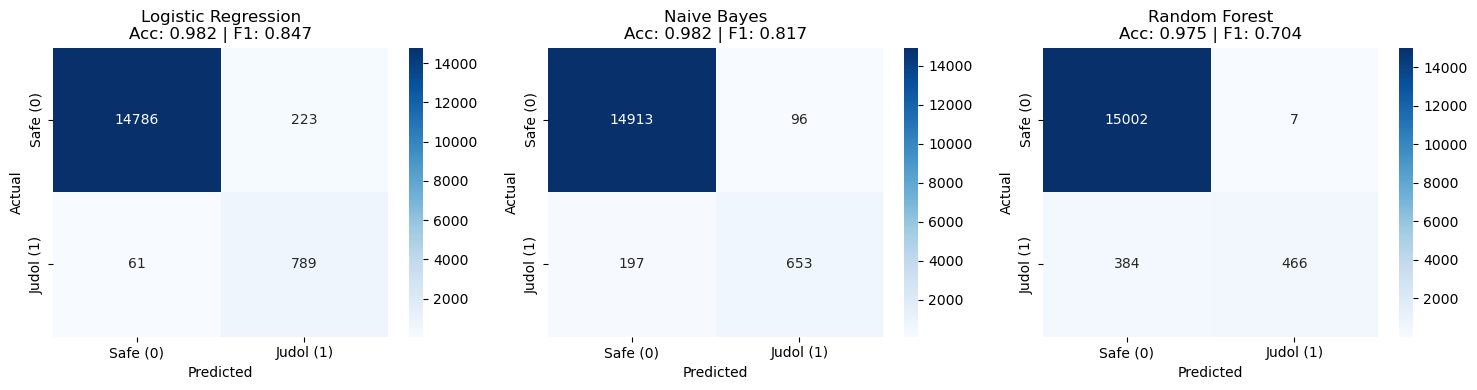

In [38]:
# Plot confusion matrix untuk semua TF-IDF models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_tfidf = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('Random Forest', y_pred_rf)
]

for ax, (name, y_pred) in zip(axes, models_tfidf):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Safe (0)', 'Judol (1)'],
                yticklabels=['Safe (0)', 'Judol (1)'])
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred):.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [39]:
# Classification Report - Best TF-IDF Model
print('=== Classification Report: Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Safe (0)', 'Judol (1)']))

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

    Safe (0)       1.00      0.99      0.99     15009
   Judol (1)       0.78      0.93      0.85       850

    accuracy                           0.98     15859
   macro avg       0.89      0.96      0.92     15859
weighted avg       0.98      0.98      0.98     15859



---
# PART B: LSTM Deep Learning
---

## 7. Tokenization untuk LSTM

In [40]:
# Hyperparameters
MAX_WORDS = 20000
MAX_LEN = 100
EMBEDDING_DIM = 128

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, char_level=False, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size: {len(tokenizer.word_index)}')
print(f'Train shape: {X_train_pad.shape}')

Vocabulary size: 67179
Train shape: (63436, 100)


## 8. Build & Train LSTM Model

In [41]:
# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f'Class weights: {class_weight_dict}')

Class weights: {0: np.float64(0.5283075436813964), 1: np.float64(9.331568108267138)}


In [42]:
# Build Bidirectional LSTM model
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Train with epochs=100 and patience=5
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print(f'\nTraining stopped at epoch: {len(history.history["loss"])}')

Epoch 1/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 144s 153ms/step - accuracy: 0.9206 - loss: 0.2568 - val_accuracy: 0.9708 - val_loss: 0.1276
Epoch 2/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 135s 151ms/step - accuracy: 0.9735 - loss: 0.0983 - val_accuracy: 0.9603 - val_loss: 0.1144
Epoch 3/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 135s 151ms/step - accuracy: 0.9824 - loss: 0.0561 - val_accuracy: 0.9625 - val_loss: 0.1086
Epoch 4/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 145s 162ms/step - accuracy: 0.9891 - loss: 0.0367 - val_accuracy: 0.9633 - val_loss: 0.1311
Epoch 5/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 137s 153ms/step - accuracy: 0.9882 - loss: 0.0440 - val_accuracy: 0.9732 - val_loss: 0.1066
Epoch 6/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 215s 241ms/step - accuracy: 0.9917 - loss: 0.0328 - val_accuracy: 0.9584 - val_loss: 0.1461
Epoch 7/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 225s 252ms/step - accuracy: 0.9939 - loss: 0.0247 - val_accuracy: 0.9674 - val_loss: 0.1567
Epoch 8/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 222s 249ms/step - accuracy: 

## 9. Training Metrics Table (Loss, Accuracy, Val_Loss, Val_Acc)

In [44]:
# Create metrics table
metrics_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Loss': history.history['loss'],
    'Accuracy': history.history['accuracy'],
    'Val_Loss': history.history['val_loss'],
    'Val_Accuracy': history.history['val_accuracy']
})

print('=== LSTM Training Metrics per Epoch ===')
print(metrics_df.to_string(index=False))

# Best epoch
best_epoch = metrics_df['Val_Loss'].idxmin() + 1
print(f'\nBest Epoch (lowest val_loss): {best_epoch}')
print(metrics_df.iloc[best_epoch-1])

=== LSTM Training Metrics per Epoch ===
 Epoch     Loss  Accuracy  Val_Loss  Val_Accuracy
     1 0.256802  0.920619  0.127563      0.970839
     2 0.098347  0.973516  0.114419      0.960277
     3 0.056123  0.982414  0.108628      0.962484
     4 0.036675  0.989123  0.131066      0.963272
     5 0.044031  0.988247  0.106584      0.973203
     6 0.032847  0.991715  0.146111      0.958386
     7 0.024708  0.993887  0.156719      0.967371
     8 0.023183  0.994150  0.110037      0.976198
     9 0.020984  0.995201  0.107005      0.978720
    10 0.020087  0.995919  0.156023      0.967686

Best Epoch (lowest val_loss): 5
Epoch           5.000000
Loss            0.044031
Accuracy        0.988247
Val_Loss        0.106584
Val_Accuracy    0.973203
Name: 4, dtype: float64


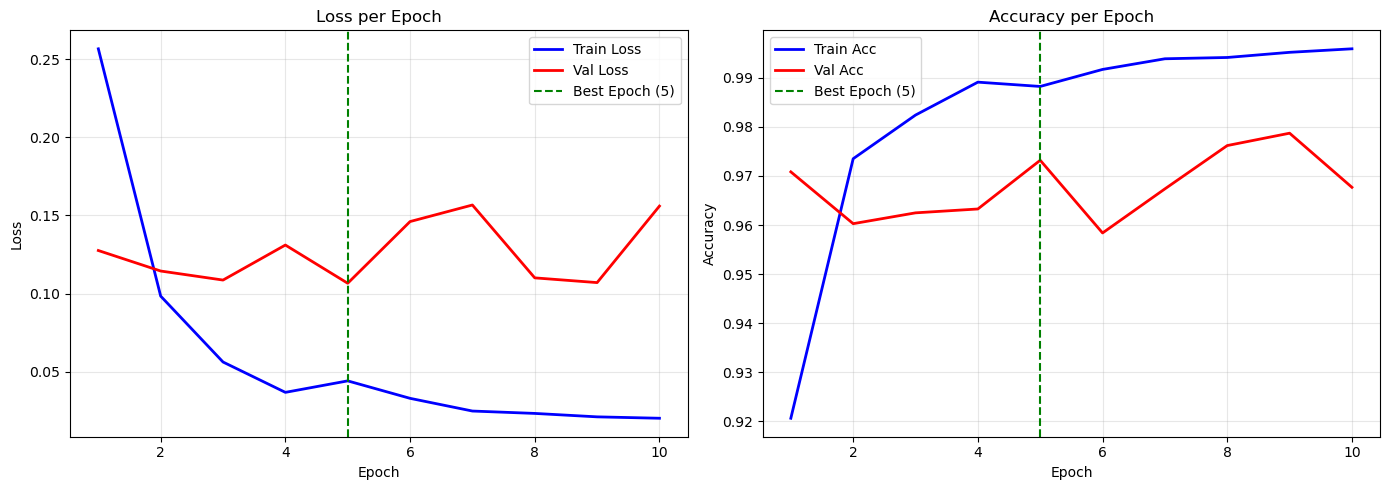

In [45]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(metrics_df['Epoch'], metrics_df['Loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(metrics_df['Epoch'], metrics_df['Val_Loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(metrics_df['Epoch'], metrics_df['Accuracy'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(metrics_df['Epoch'], metrics_df['Val_Accuracy'], 'r-', label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Evaluate LSTM & Confusion Matrix

In [46]:
# Predict
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

print(f'LSTM Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}')
print(f'LSTM F1-Score: {f1_score(y_test, y_pred_lstm):.4f}')

496/496 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step
LSTM Accuracy: 0.9753
LSTM F1-Score: 0.7910


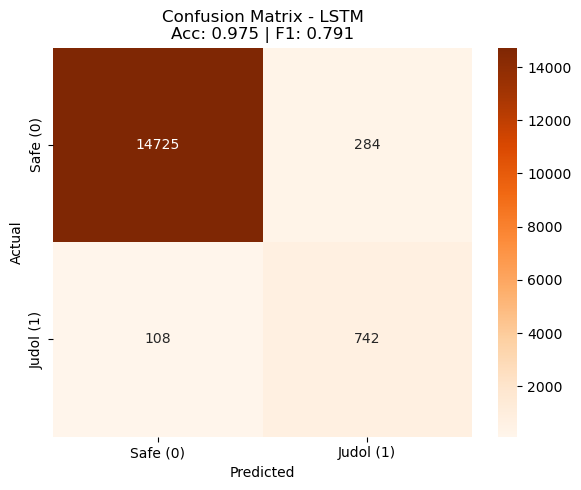


=== Classification Report: LSTM ===
              precision    recall  f1-score   support

    Safe (0)       0.99      0.98      0.99     15009
   Judol (1)       0.72      0.87      0.79       850

    accuracy                           0.98     15859
   macro avg       0.86      0.93      0.89     15859
weighted avg       0.98      0.98      0.98     15859



In [47]:
# Confusion Matrix - LSTM
plt.figure(figsize=(6, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Safe (0)', 'Judol (1)'],
            yticklabels=['Safe (0)', 'Judol (1)'])
plt.title(f'Confusion Matrix - LSTM\nAcc: {accuracy_score(y_test, y_pred_lstm):.3f} | F1: {f1_score(y_test, y_pred_lstm):.3f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\n=== Classification Report: LSTM ===')
print(classification_report(y_test, y_pred_lstm, target_names=['Safe (0)', 'Judol (1)']))

---
# Comparison: All Models
---

In [48]:
# Compare all models
results = [
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_score(y_test, y_pred_lr), 'F1-Score': f1_score(y_test, y_pred_lr)},
    {'Model': 'Naive Bayes', 'Accuracy': accuracy_score(y_test, y_pred_nb), 'F1-Score': f1_score(y_test, y_pred_nb)},
    {'Model': 'Random Forest', 'Accuracy': accuracy_score(y_test, y_pred_rf), 'F1-Score': f1_score(y_test, y_pred_rf)},
    {'Model': 'Bidirectional LSTM', 'Accuracy': accuracy_score(y_test, y_pred_lstm), 'F1-Score': f1_score(y_test, y_pred_lstm)},
]

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print('\n=== MODEL COMPARISON ===')
print(results_df.to_string(index=False))


=== MODEL COMPARISON ===
              Model  Accuracy  F1-Score
Logistic Regression  0.982092  0.847476
        Naive Bayes  0.981525  0.816760
 Bidirectional LSTM  0.975282  0.791045
      Random Forest  0.975345  0.704460


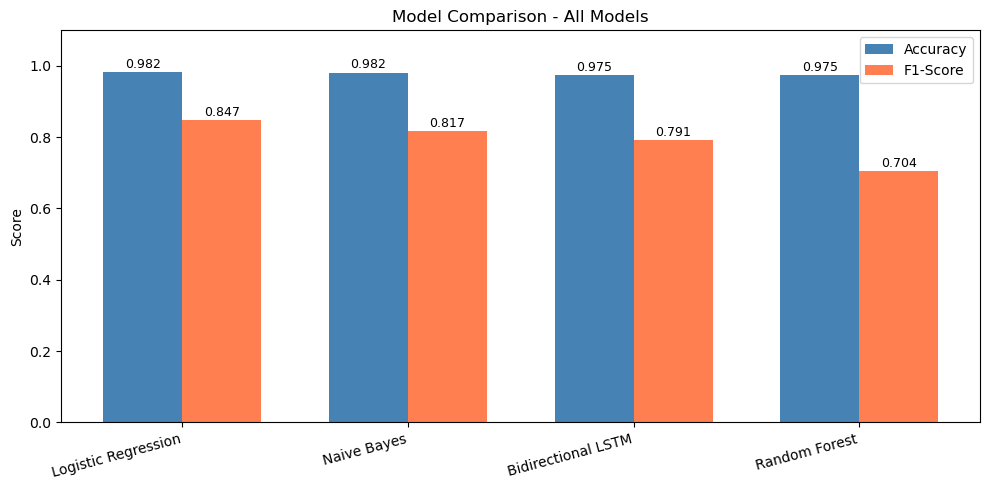

In [49]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Models')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Save Models

In [50]:
import os
os.makedirs('../models', exist_ok=True)

# Save TF-IDF
joblib.dump(lr_model, '../models/judol_logreg_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

# Save LSTM
lstm_model.save('../models/judol_lstm_model.keras')
joblib.dump(tokenizer, '../models/lstm_tokenizer.pkl')

print('All models saved!')

All models saved!


## 12. Test Inference

In [51]:
def predict_tfidf(text):
    X = tfidf.transform([text])
    pred = lr_model.predict(X)[0]
    prob = lr_model.predict_proba(X)[0][1]
    return pred, prob

def predict_lstm(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob = lstm_model.predict(pad, verbose=0)[0][0]
    pred = 1 if prob > 0.5 else 0
    return pred, prob

# Test
test_comments = [
    'Video bagus bang, lanjutkan!',
    'Gaskeun join di MINI1221 banyak bonus!',
    'Buruan join di 𝐏𝐀𝐒𝐓𝐄𝟒𝐃 banyak cuan!',
    '2,8rb subs skrng pasti bakalan jutaan subs smangat',
    'Semangat terus kak, kontennya bagus!',
]

print('\n=== PREDICTION TEST ===')
print('-' * 80)
for comment in test_comments:
    pred_tf, prob_tf = predict_tfidf(comment)
    pred_lstm, prob_lstm = predict_lstm(comment)
    
    label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
    label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'
    
    print(f'Text: {comment[:50]}...')
    print(f'  TF-IDF: [{label_tf}] ({prob_tf:.2%})')
    print(f'  LSTM:   [{label_lstm}] ({prob_lstm:.2%})')
    print()


=== PREDICTION TEST ===
--------------------------------------------------------------------------------
Text: Video bagus bang, lanjutkan!...
  TF-IDF: [SAFE] (37.87%)
  LSTM:   [SAFE] (0.39%)

Text: Gaskeun join di MINI1221 banyak bonus!...
  TF-IDF: [JUDOL] (83.24%)
  LSTM:   [JUDOL] (100.00%)

Text: Buruan join di 𝐏𝐀𝐒𝐓𝐄𝟒𝐃 banyak cuan!...
  TF-IDF: [JUDOL] (99.86%)
  LSTM:   [JUDOL] (99.99%)

Text: 2,8rb subs skrng pasti bakalan jutaan subs smangat...
  TF-IDF: [SAFE] (25.73%)
  LSTM:   [JUDOL] (99.82%)

Text: Semangat terus kak, kontennya bagus!...
  TF-IDF: [SAFE] (38.39%)
  LSTM:   [SAFE] (6.74%)

